Loading merged dataset...
Rows after dropping NaNs: 278507

OLS: Predicting Global North/South (binary)
                            OLS Regression Results                            
Dep. Variable:          target_binary   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     742.0
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:01:42   Log-Likelihood:            -1.7809e+05
No. Observations:              278507   AIC:                         3.562e+05
Df Residuals:                  278497   BIC:                         3.563e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------

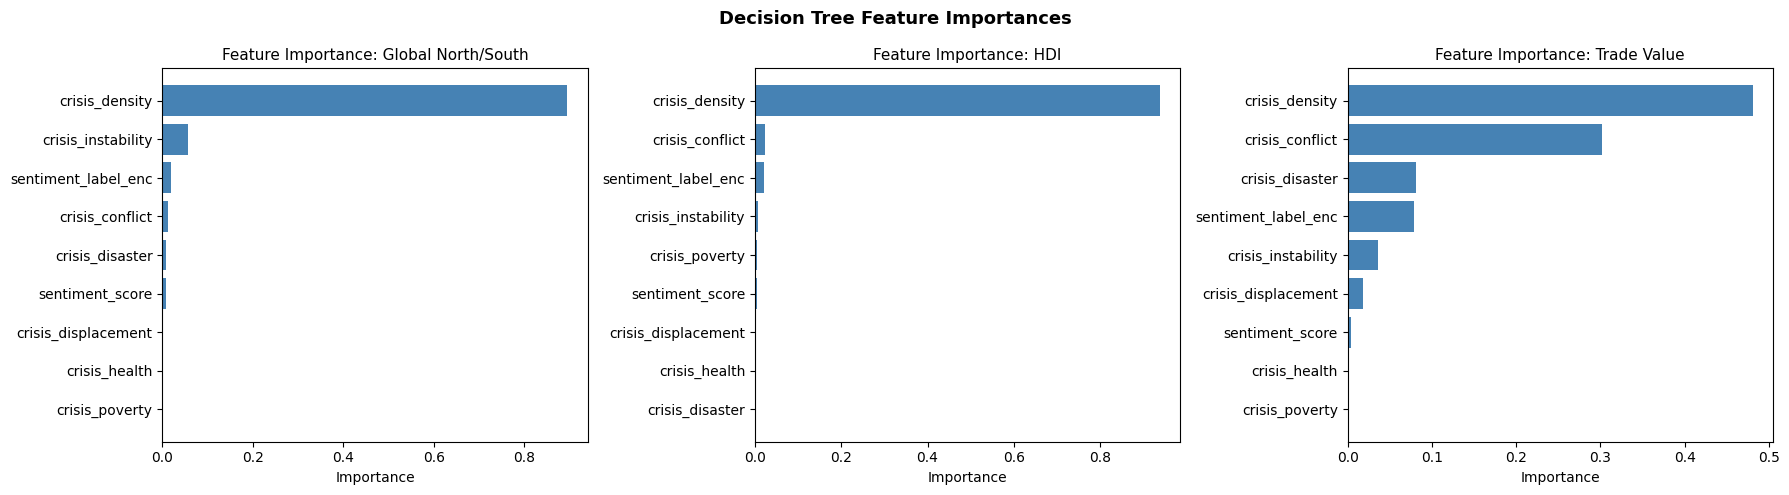

Saved: feature_importances.png


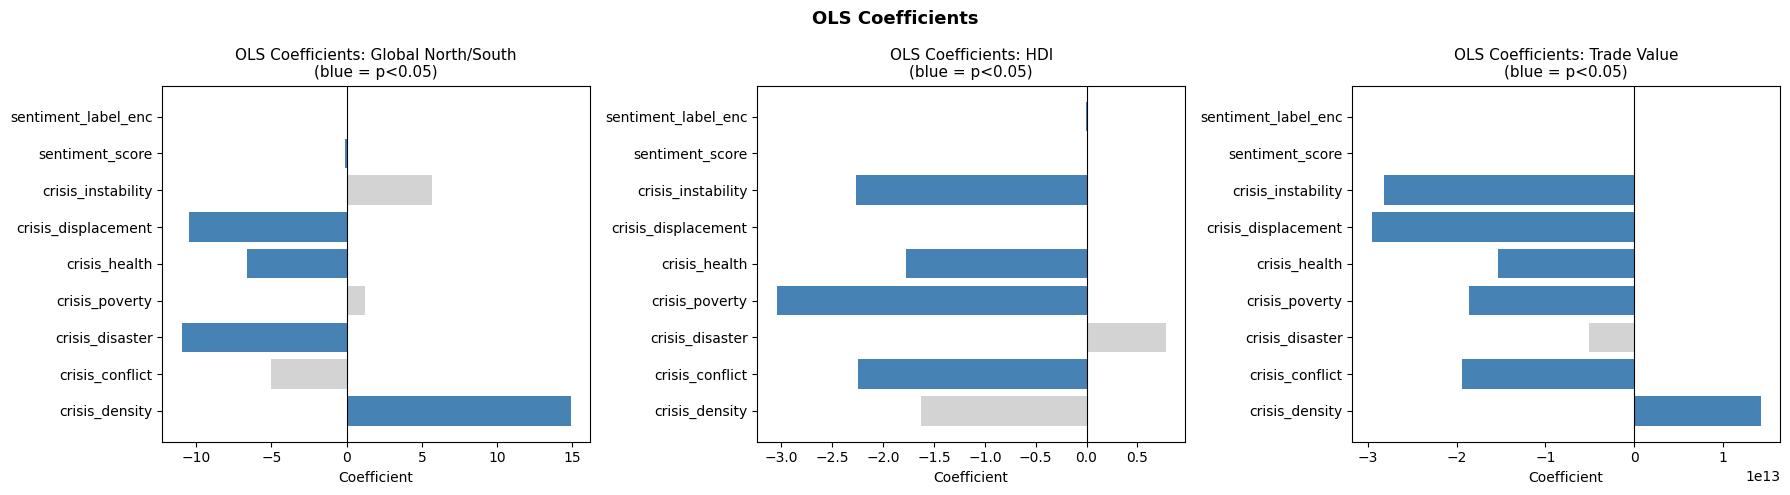

Saved: ols_coefficients.png


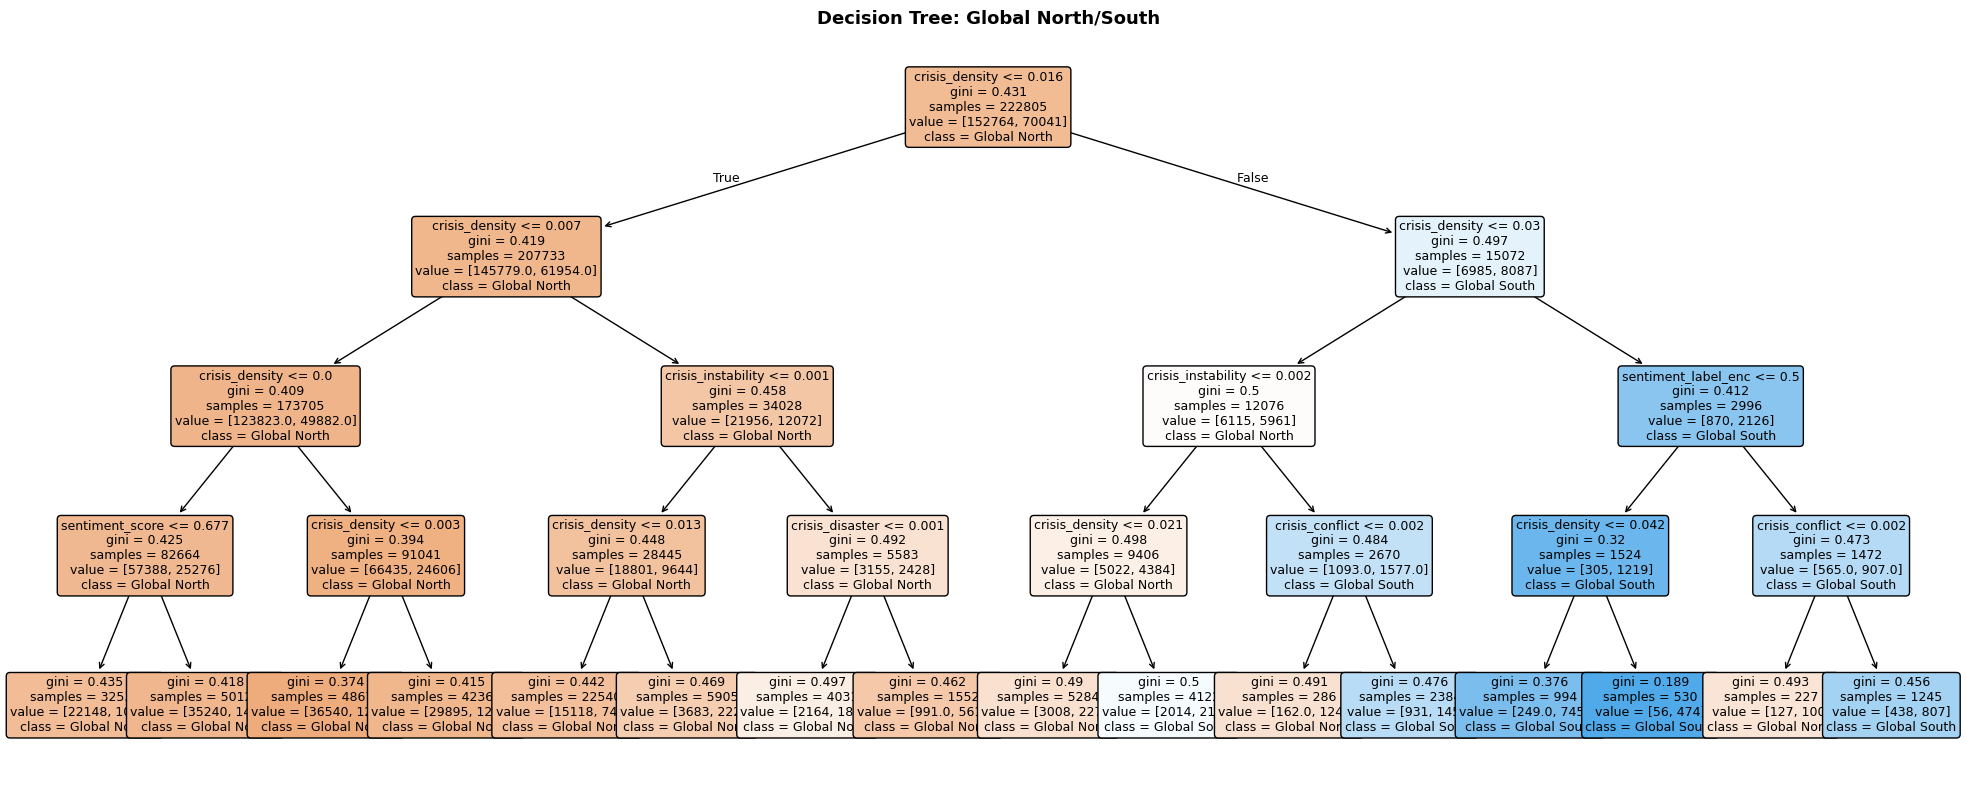

Saved: tree_binary.png


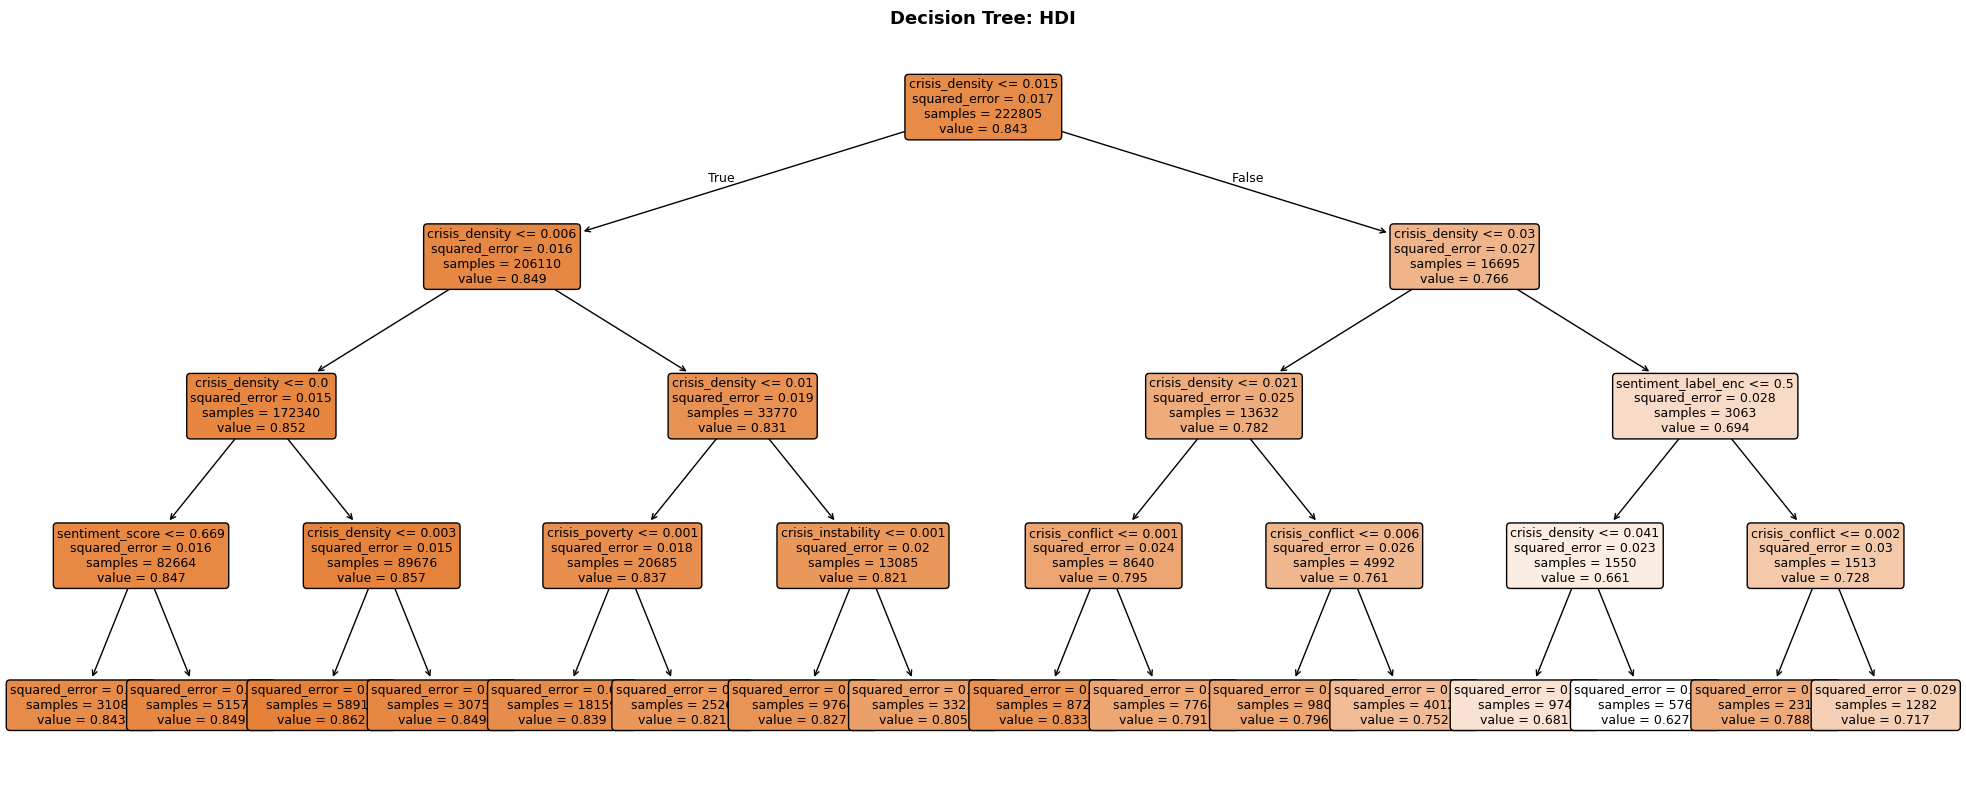

Saved: tree_hdi.png


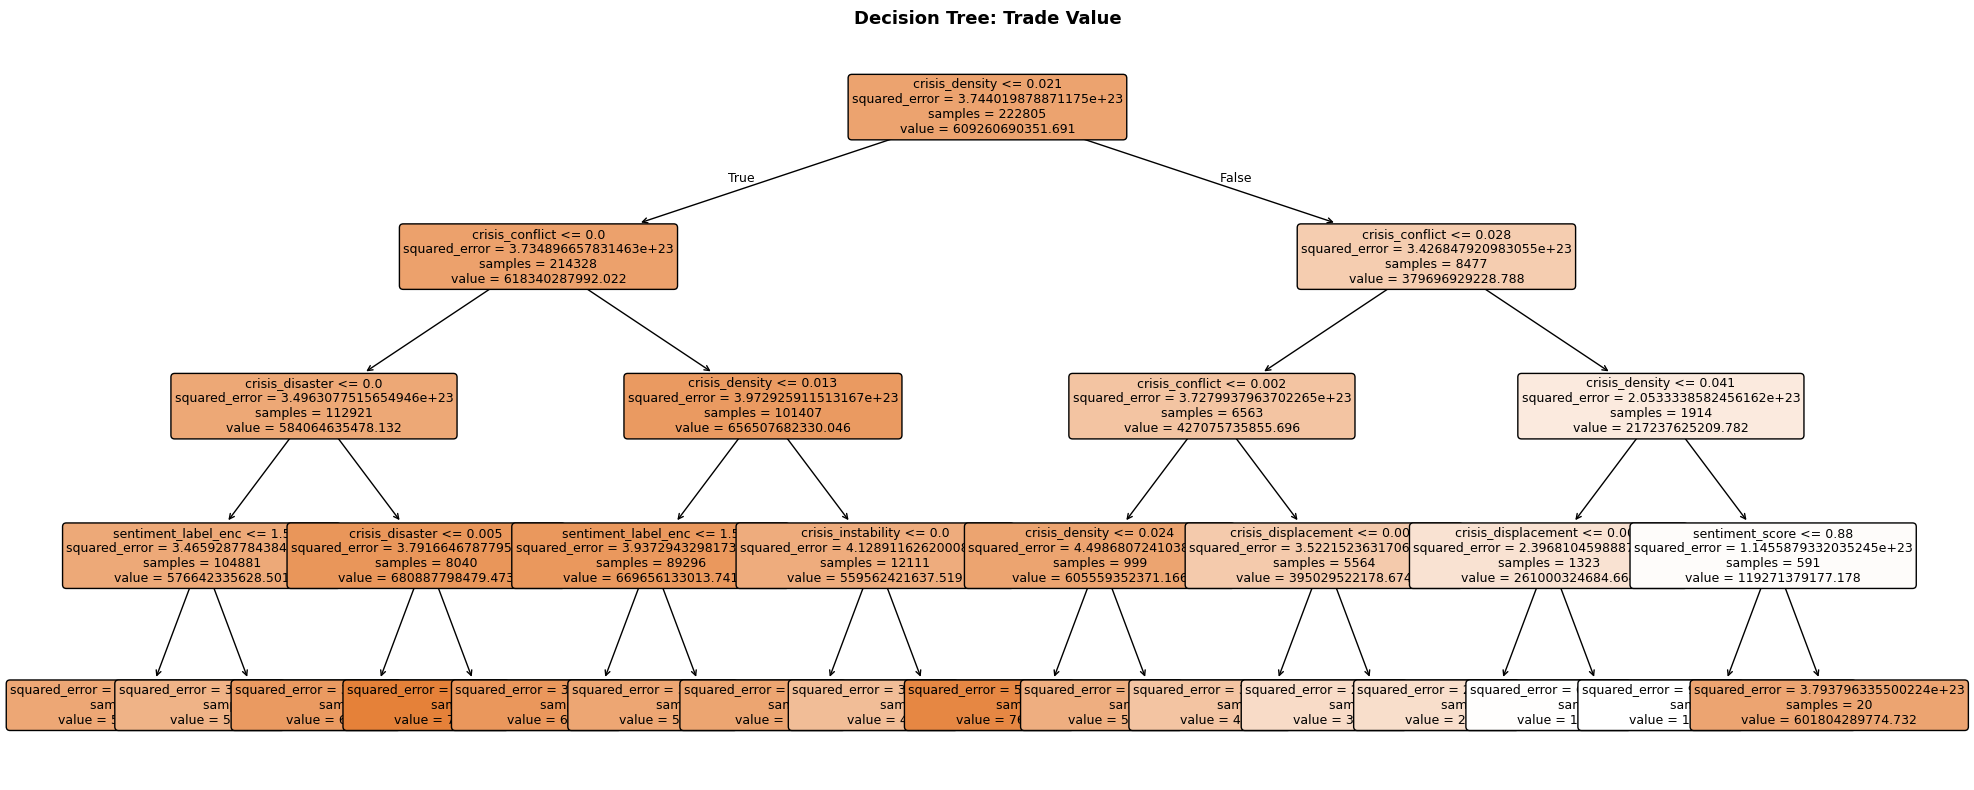

Saved: tree_trade.png

All done!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm

# ── 1. Load merged dataset ───────────────────────────────────────────────────
print("Loading merged dataset...")
df = pd.read_parquet("merged_dataset.parquet")

# ── 2. Define features ───────────────────────────────────────────────────────
CRISIS_COLS = [
    "crisis_density", "crisis_conflict", "crisis_disaster",
    "crisis_poverty", "crisis_health", "crisis_displacement", "crisis_instability"
]
FEATURE_COLS = CRISIS_COLS + ["sentiment_score"]

# Encode sentiment_label as numeric (in case it's useful later)
le = LabelEncoder()
df["sentiment_label_enc"] = le.fit_transform(df["sentiment_label"].astype(str))
FEATURE_COLS_WITH_LABEL = FEATURE_COLS + ["sentiment_label_enc"]

# Drop rows with missing values in features or targets
targets = ["global_north_or_south", "HDI", "trade_value"]
df_clean = df[FEATURE_COLS_WITH_LABEL + targets].dropna()

print(f"Rows after dropping NaNs: {len(df_clean)}")

X = df_clean[FEATURE_COLS_WITH_LABEL]

# Encode global north/south as binary (0/1)
df_clean["target_binary"] = le.fit_transform(df_clean["global_north_or_south"].astype(str))
binary_classes = le.classes_  # so we know which is 0 and which is 1

# ── 3. Helper: OLS ───────────────────────────────────────────────────────────
def run_ols(X, y, title):
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()
    print(f"\n{'='*60}")
    print(f"OLS: {title}")
    print(model.summary())
    return model

# ── 4. Helper: Decision Tree ─────────────────────────────────────────────────
def run_tree(X, y, task, title, class_names=None):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    if task == "classification":
        model = DecisionTreeClassifier(max_depth=4, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print(f"\n{'='*60}")
        print(f"Decision Tree: {title}")
        print(classification_report(y_test, y_pred, target_names=class_names))
    else:
        model = DecisionTreeRegressor(max_depth=4, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        print(f"\n{'='*60}")
        print(f"Decision Tree: {title}")
        print(f"R²: {r2:.4f}  |  RMSE: {rmse:.4f}")
    return model

# ── 5. Run models ────────────────────────────────────────────────────────────

# --- Global North/South (binary classification) ---
y_binary = df_clean["target_binary"]
ols_binary  = run_ols(X, y_binary,  "Predicting Global North/South (binary)")
tree_binary = run_tree(X, y_binary, "classification", "Global North/South", class_names=binary_classes)

# --- HDI (regression) ---
y_hdi = df_clean["HDI"]
ols_hdi  = run_ols(X, y_hdi,  "Predicting HDI")
tree_hdi = run_tree(X, y_hdi, "regression", "HDI")

# --- Trade Value (regression) ---
y_trade = df_clean["trade_value"]
ols_trade  = run_ols(X, y_trade,  "Predicting Trade Value")
tree_trade = run_tree(X, y_trade, "regression", "Trade Value")

# ── 6. Visualisations ────────────────────────────────────────────────────────
feature_names = list(X.columns)

def plot_feature_importance(model, title, ax):
    importances = model.feature_importances_
    indices = np.argsort(importances)
    ax.barh([feature_names[i] for i in indices], importances[indices], color="steelblue")
    ax.set_title(f"Feature Importance: {title}", fontsize=11)
    ax.set_xlabel("Importance")

def plot_ols_coefs(model, title, ax):
    coefs = model.params.drop("const", errors="ignore")
    pvals = model.pvalues.drop("const", errors="ignore")
    colors = ["steelblue" if p < 0.05 else "lightgrey" for p in pvals]
    ax.barh(coefs.index, coefs.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"OLS Coefficients: {title}\n(blue = p<0.05)", fontsize=11)
    ax.set_xlabel("Coefficient")

# --- Figure 1: Feature importances (3 trees) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_feature_importance(tree_binary, "Global North/South", axes[0])
plot_feature_importance(tree_hdi,    "HDI",                axes[1])
plot_feature_importance(tree_trade,  "Trade Value",        axes[2])
plt.suptitle("Decision Tree Feature Importances", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importances.png")

# --- Figure 2: OLS coefficients (3 models) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_ols_coefs(ols_binary, "Global North/South", axes[0])
plot_ols_coefs(ols_hdi,    "HDI",                axes[1])
plot_ols_coefs(ols_trade,  "Trade Value",        axes[2])
plt.suptitle("OLS Coefficients", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ols_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ols_coefficients.png")

# --- Figure 3: Decision tree diagrams (3 trees) ---
for model, title, fname in [
    (tree_binary, "Global North/South", "tree_binary.png"),
    (tree_hdi,    "HDI",                "tree_hdi.png"),
    (tree_trade,  "Trade Value",        "tree_trade.png"),
]:
    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(model, feature_names=feature_names,
              filled=True, rounded=True, fontsize=9, ax=ax,
              class_names=binary_classes if title == "Global North/South" else None)
    ax.set_title(f"Decision Tree: {title}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

print("\nAll done!")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm

# ── 1. Load merged dataset ───────────────────────────────────────────────────
print("Loading merged dataset...")
df = pd.read_parquet("merged_dataset.parquet")

print(df.columns.tolist())

Loading merged dataset...
['id', 'sentiment_label', 'sentiment_score', 'crisis_density', 'crisis_conflict', 'crisis_disaster', 'crisis_poverty', 'crisis_health', 'crisis_displacement', 'crisis_instability', 'primary_country', 'country_freq', 'iso2', 'country', 'global_north_or_south', 'trade_value', 'HDI']
